# Adaptive PDE discretizations on Cartesian grids, Taichi implementations

## Volume : Eikonal equations

## Part : Algorithmic tutorial

## Chapter : Fast Marching, Fast Sweeping, et al

$\newcommand\bZ{\mathbb{Z}}\newcommand\bR{\mathbb{R}}\newcommand\bN{\mathbb{N}}\newcommand\cO{\mathcal{O}}$

**Discretization of the eikonal equation.**
This notebook describes the numerical solution of the standard eikonal equation
$$
    \|\nabla u(x)\| = c(x),
$$
for each point $x \in \Omega$ of a given domain, with suitable boundary conditions.

We discretize this PDE using the standard scheme by E. Rouy and A. Tourin.
$$
    \sum_{1 \leq i \leq d} \max\{0,u(x)-u(x-h b_i), u(x)-u(x+h b_i)\}^2 = c(x)^2 h^2,
$$
for each point $x \in X$ of a the Cartesian grid set $X = \Omega \cap h \bZ^d$, where $h>0$ is the grid scale, again with suitable boundary conditions.

The resulting coupled system of non-linear equations can be rephrased as a fixed point problem: 
$$
    u(x) = \Lambda u(x),
$$
for each $x \in X$, where 
the value $\lambda = \Lambda u(x)$ is defined as the unique solution to the univariate equation
$$
    \sum_{1 \leq i \leq d} \max\{0,\lambda-u(x-h b_i), \lambda-u(x+h b_i)\}^2 = c(x)^2 h^2.
$$
This update operator is 
- Monotone : if $u \leq v$ on X, then $\Lambda u \leq \Lambda v$.
- Causal : informally, this means that $\Lambda u(x)$ only depends on the values $u(y)$ such that $u(y)\leq \Lambda u(x)$.

The FMM, mentioned below, requires a causal and monotone scheme, whereas the other methods only require monotony, which often simplifies their extension to more complex settings (e.g. triangular meshes rather than grids, or anisotropic metrics).

**Iteration policy.**
The numerical solution $u: X \to \bR$ is computed by applying the updating the values
$$
    u(x_n) \gets \Lambda u(x_n)
$$
of a mutable map, initialized as $u \equiv \infty$. Several iteration policies, defining the sequence $(x_n)_{n \in \bN}$, are considered in this notebook:
- FMM (Tsitsiklis, 1995), sequential, complexity $\cO(N\ln N)$. The *Fast Marching Method* (FMM) is closely related with Dijkstra's algorithm. The sequence $(x_n)_{n \in \bN}$ is defined through a priority queue. 
- AGSI (Bornemann et al, 2006), sequential, complexity between $\cO(N)$ and $\cO(N^{1+1/d})$ depending on the test case difficulty (estimated). The sequence $(x_n)_{n \in \bN}$ is defined through a FIFO queue.
- FS (Zhao, 2005), somewhat parallel, similar empirical complexity. The sequence $(x_n)_{n \in \bN}$ is fixed a-priori: column by column, line by line, etc

There are other iteration policies, such as the fast iterative method (FIM, Whitaker et al, 2008). Recently, a quasi-linear complexity guarantee was established for a narrow band method (Mirebeau, Mansour, 2025). Special data structures can also be considered in view of GPU acceleration. We do not consider these more complex methods in the following.

<!---
- Global Iteration, embarassingly parallel, complexity $\cO(N^{1+1/d})$.
--->



## 0. Importing the required libraries

In [1]:
#!pip install taichi # Uncomment on Colab

In [2]:
#!pip install agd # Uncomment on Colab

In [3]:
import numpy as np
import taichi as ti
from matplotlib import pyplot as plt

[Taichi] version 1.7.2, llvm 15.0.7, commit 0131dce9, osx, python 3.11.11


[I 06/26/25 13:52:35.695 7347244] [shell.py:_shell_pop_print@23] Graphical python shell detected, using wrapped sys.stdout


### 0.1 Additional configuration

We use the Taichi, which allows just in time compilation on various platforms of code written in python.

In [4]:
float_t = ti.f32
ti.init(arch=ti.cpu,default_fp=float_t)
np.set_printoptions(linewidth=2000)

[Taichi] Starting on arch=arm64


### 0.2 Queue structures

In [5]:
@ti.data_oriented
class priority_queue:
	"""
	A priority queue implemented using a binary heap.
	- capacity : one should always have capacity >= size
	
	"""
	# Strongly inspired by : https://github.com/g1n0st/taichi-ferrofluid/blob/main/priority_queue.py

	def __init__(self,prio_type,elem_type,capacity=1023):
		self.prio = ti.field(dtype=prio_type, shape=capacity+1) # Largest priority goes on top
		self.elem = ti.field(dtype=elem_type, shape=capacity+1) # Attached value to a priority
		self._size = ti.field(dtype=ti.i32, shape=()); self._size[None]=0
		self._capacity = ti.field(dtype=ti.i32, shape=()); self._capacity[None]=capacity

	@property
	@ti.pyfunc
	def capacity(self): return self._capacity[None]

	#@ti.pyfunc
	#def capacity(self): return self.elem.shape[0]

	@property
	@ti.pyfunc
	def size(self): return self._size[None]

	@ti.pyfunc
	def clear(self): self._size[None]=0

	@ti.pyfunc
	def empty(self): return self.size==0

	@ti.pyfunc
	def top(self):
		assert not self.empty()
		return self.prio[1],self.elem[1]

	@ti.pyfunc
	def swap(self,i,j): # Swap queue elements of index i and j
		prio_tmp = self.prio[i]; self.prio[i]=self.prio[j]; self.prio[j] = prio_tmp
		elem_tmp = self.elem[i]; self.elem[i]=self.elem[j]; self.elem[j] = elem_tmp

	@ti.pyfunc
	def pop(self):
		assert not self.empty()
		# Put last element on top, and erase it
		self.prio[1] = self.prio[self.size]; self.elem[1]=self.elem[self.size]
		self._size[None]-=1
		parent = 1
		child  = 2*parent # Children are 2*parent and 2*parent+1 in binary tree
		while child<=self.size: # Perform swaps to restore hierarchy in binary tree
			if child+1<=self.size and self.prio[child+1]>self.prio[child]: child=child+1
			if self.prio[child]<=self.prio[parent]: break # Priority ordering already satisfied
			self.swap(parent,child)
			parent=child; child=2*child
		
	@ti.pyfunc
	def push(self,prio,elem):
		self._size[None]+=1
		assert self.size<self.prio.shape[0] # Capacity increase can only be done from Python scope
		self.prio[self.size] = prio; self.elem[self.size] = elem # Put new element last
		child = self.size
		parent = child//2 # Parent in binary tree
		while parent>0: # Restore hierarchical order
			if self.prio[parent]>self.prio[child]: break
			self.swap(parent,child)
			child=parent; parent=child//2


	def set_capacity(self,capacity=None):
		"""
		Change the capacity of the priority queue. (capacity >= size+1)
		- capacity (default = 2*old_capacity) : new capacity
		"""
		if capacity is None: capacity = 2*self.capacity+1
		else: assert capacity>=self.size

		prio = ti.field(dtype=self.prio.dtype, shape=capacity+1) # Largest priority goes on top
		elem = ti.field(dtype=self.elem.dtype, shape=capacity+1) # Attached value to a priority
		@ti.kernel
		def copy_data():
			for i in range(self.size+1):
				prio[i] = self.prio[i]
				elem[i] = self.elem[i]
		copy_data()
		self.prio = prio
		self.elem = elem
		self._capacity[None] = capacity


@ti.data_oriented
class fifo_queue:
	"""A Fist In First Out (FIFO) queue"""
	def __init__(self,elem_type,capacity=1023):
		self.elem = ti.field(dtype=elem_type, shape=capacity+1)
		self.begin = ti.field(dtype=ti.i32, shape=()); self.begin.fill(0)
		self.end = ti.field(dtype=ti.i32, shape=()); self.end.fill(0)
		self._capacity = ti.field(dtype=ti.i32,shape=()); self._capacity.fill(capacity)

	@ti.pyfunc
	def front(self): return self.elem[self.begin[None]]

	@ti.pyfunc
	def pop(self):
		self.begin[None]+=1
		if self.begin[None]==self.elem.shape[0]: self.begin[None]=0
		assert self.begin!=self.end

	@ti.pyfunc
	def push(self,elem):
		self.elem[self.end[None]]=elem
		self.end[None]+=1
		if self.end[None]==self.elem.shape[0]: self.end[None]=0

	@property
	@ti.pyfunc
	def capacity(self): return self._capacity[None]

	@property
	@ti.pyfunc
	def _container_size(self): return self.elem.shape[0] # == capacity+1

	@ti.pyfunc
	def empty(self): return self.begin[None]==self.end[None] 

	@property
	@ti.pyfunc
	def size(self):
		s = self.end[None]-self.begin[None]
		return s if s>=0 else (s+self._container_size)

	def set_capacity(self,capacity=None):
		if capacity is None: capacity = 2*self.capacity+1
		else: assert capacity>=self.size

		elem = ti.field(dtype=self.elem.dtype, shape=capacity+1)
		@ti.kernel
		def copy_data():
			beg,end = self.begin[None],self.end[None]
			if beg<=end:
				for i in range(self.size):
					elem[i] = self.elem[beg+i]
			else:
				rem = self._container_size-beg
				for i in range(rem): elem[i] = self.elem[beg+i]
				for i in range(end): elem[rem+i] = self.elem[i]
		copy_data()
		self.elem = elem
		self.end[None] = self.size
		self.begin[None] = 0
		self._capacity[None] = capacity

## 1. The update operator

We implement below the update operator associated with the two dimensional Rouy-Tourin scheme.
In other words, we compute the value $\lambda = \Lambda u(x,y) \in \bR$ such that 
$$
    \max \{0,\lambda - u_x\}^2 + \max \{0,\lambda-u_y\}^2 = h^2 c(x,y)^2
$$
where 
$$
    u_x = \min\{u(x+h,y), u(x-h,y)\}, \quad u_y = \min \{u(x,y+h),u(x,y-h)\}.
$$
Up to a rescaling argument, we can assume that $h=1$. Up to exchanging the roles of $u_x$ and $u_y$, we can assume that $u_x \leq u_y$. Under these assumptions, we can characterize the solution to the above non-linear equation by distinguishing to two cases:
- (linear update) if $\lambda \leq u_y$, then $\lambda = u_x + c(x,y)$.
- (quadratic update) if $\lambda \geq u_y$, then $\lambda$ is the largest root of the following quadratic equation:
  $$
  (\lambda-u_x)^2+(\lambda-u_y)^2 = c(x,y)^2.
  $$

<!---ExoEN
Implement the computation of the solution $\lambda$ of the univariate non-linear equation, by distinguishing two cases as above.
--->

<!---ExoCode
@ti.data_oriented
class RouyTourinScheme:
    """
    Update associated with the Rouy-Tourin discretization of the eikonal equation.
    - cost : the cost function. 
    """
    def __init__(self,cost):
        self.cost = cost
        self.values = ti.field(dtype=cost.dtype,shape=cost.shape)
        self.values.fill(np.inf)
        self.nupdates = ti.field(dtype=ti.i64,shape=())
        self.nupdates[None]=0 # Update counter
        
    @ti.pyfunc
    def update(self,p):
        """Compute the update at a given point p of the grid"""
        u = ti.static(self.values)
        x,y = p
        nX,nY = self.cost.shape
        λ = np.inf
        cost = self.cost[x,y]
        self.nupdates[None]+=1
        if 0<x and x<nX-1 and 0<y and y<nY-1 and cost<np.inf: 
            # Get the minimal neighbor values, along the horizontal and vertical axes
            ux = min(u[x-1,y],u[x+1,y])
            uy = min(u[x,y-1],u[x,y+1])
            
            # Sort the values, and compute the update from the axis directions
            ux,uy = min(ux,uy),max(ux,uy)
            λ = # TODO ! First try the linear update.

            # Compute the update by solving a quadratic equation, if adequate
            if uy<λ:
                λ = # TODO ! Implement the quadratic solution.
        return λ

    @ti.pyfunc
    def neigh(self,p,callback:ti.template()):
        """Enumerate the neighbors of the point p"""
        x,y = p
        nX,nY = self.cost.shape
        if 0<x:    callback(ti.math.ivec2(x-1,y))
        if x<nX-1: callback(ti.math.ivec2(x+1,y))
        if 0<y:    callback(ti.math.ivec2(x,y-1))
        if y<nY-1: callback(ti.math.ivec2(x,y+1))
--->

In [6]:
@ti.data_oriented
class RouyTourinScheme:
    """
    Update associated with the Rouy-Tourin discretization of the eikonal equation.
    - cost : the cost function. 
    """
    def __init__(self,cost):
        self.cost = cost # The cost function in the r.h.s of the eikonal equation
        self.values = ti.field(dtype=cost.dtype,shape=cost.shape) 
        self.values.fill(np.inf) # The numerical solution (mutable, initialized to infty)
        self.nupdates = ti.field(dtype=ti.i64,shape=()) 
        self.nupdates[None]=0 # Update counter
        
    @ti.pyfunc
    def update(self,p):
        """Compute the update at a given point p of the grid"""
        u = ti.static(self.values)
        x,y = p
        nX,nY = self.cost.shape
        λ = np.inf
        cost = self.cost[x,y]
        self.nupdates[None]+=1
        if 0<x and x<nX-1 and 0<y and y<nY-1 and cost<np.inf: 
            # Get the minimal neighbor values, along the horizontal and vertical axes
            ux = min(u[x-1,y],u[x+1,y])
            uy = min(u[x,y-1],u[x,y+1])
            
            # Sort the values, and compute the update from the axis directions
            ux,uy = min(ux,uy),max(ux,uy)
            λ = ux+cost

            # Compute the update by solving a quadratic equation, if adequate
            if uy<λ:
                Δ = max(0., 2*cost**2-(ux-uy)**2) # Discriminant (max with 0. is for roundoff errors)
                λ = (ux+uy+ti.math.sqrt(Δ))/2
        return λ

    @ti.pyfunc
    def neigh(self,p,callback:ti.template()):
        """Enumerate the neighbors of the point p"""
        x,y = p
        nX,nY = self.cost.shape
        if 0<x:    callback(ti.math.ivec2(x-1,y))
        if x<nX-1: callback(ti.math.ivec2(x+1,y))
        if 0<y:    callback(ti.math.ivec2(x,y-1))
        if y<nY-1: callback(ti.math.ivec2(x,y+1))

Let us try our update operator on a small test case.

In [7]:
cost = ti.field(dtype=float_t,shape=(5,7))
cost.fill(1)

In [8]:
scheme = RouyTourinScheme(cost)

In [9]:
@ti.pyfunc
def printme(x): print(x)

p = ti.math.ivec2(2,2) # In the domain interior
print(f"neighbors of {p=} :");
scheme.neigh(p,printme)

p = ti.math.ivec2(4,0) # A corner point, not all neighbors are present
print(f"neighbors of {p=} :");
scheme.neigh(p,printme)

neighbors of p=[2 2] :
[1 2]
[3 2]
[2 1]
[2 3]
neighbors of p=[4 0] :
[3 0]
[4 1]


In [10]:
#Test the linear update 
scheme.values[2,2]=0
assert np.allclose( scheme.update(ti.math.ivec2(2,3)), 1.)

In [11]:
#Test the quadratic update 
scheme.values[3,3]=0
assert np.allclose( scheme.update(ti.math.ivec2(2,3)), np.sqrt(2.)/2)

In [12]:
# The update counter works
scheme.nupdates[None]

2

### 1.1 Choosing the cost function


For testing, a small map where cost equals one everywhere.

In [13]:
cost = ti.field(dtype=float_t,shape=(5,7)); cost.fill(1)
#cost = ti.field(dtype=float_t,shape=(50,70)); cost.fill(1)
seed = ti.math.ivec2(3,3)

For a larger and more interesting test case, a cost map with obstacles.

In [14]:
import sys; sys.path.insert(0,'../../../AdaptiveGridDiscretizations')
from agd.Plotting import imread
im = imread("Notebooks_FMM/TestImages/centre_pompidou_800x546.png")
im = im[68:515,65:770]
dom = np.logical_and(np.logical_and(im[:,:,0]==0,im[:,:,1]==0),im[:,:,2]==255).T
cost_np = np.where(dom,1,np.inf).T

cost = ti.field(dtype=float_t,shape=cost_np.shape); cost.from_numpy(cost_np.astype(np.float32))
seed = ti.math.ivec2(40,40)

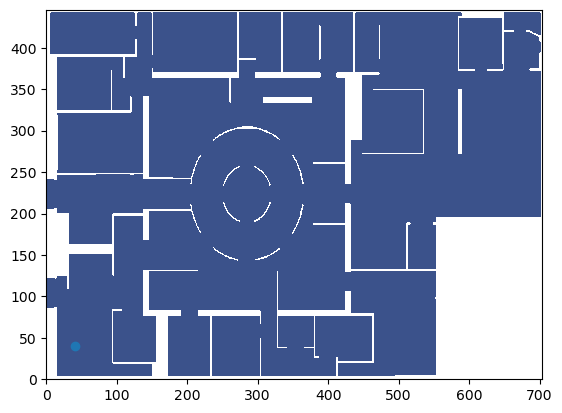

In [15]:
plt.contourf(cost_np); plt.scatter(*seed)

## 2. The Fast Marching method

The fast marching method is a generalization of Dijkstra's algorithm, which solves the fixed point discretization of the eikonal equation with quasi-linear $\cO(N\ln N)$ complexity. It requires a *causal and monotone* scheme, which is indeed the case here.

### 2.1 Priority queue

A [priority queue](https://en.wikipedia.org/wiki/Priority_queue) is a data structure with the following operations:
- `push(priority,key)` pair new $key$ value, with a corresponding priority
- `top()` access the $(priority,key)$ pair with the top priority
- `pop()` remove the $(priority,key)$ pair with the top priority

It is common top implement priority queues using a [binary heap](https://en.wikipedia.org/wiki/Binary_heap), in such way that the `push` and `pop` operations have $\cO(\ln N)$ complexity, where $N$ is the number of elements contained in the queue.
The `heapq` standard python library provides such an implementation, but it cannot be used within Taichi kernels.
The agdt library provides a [basic implementation](https://github.com/Mirebeau/AdaptiveGridDiscretizations_Taichi/blob/main/agdt/Eikonal/Queue.py) which is Taichi compatible, except for the `set_capacity` method which resizes the internal containers to accomodate for more data, and must be called from the python scope.


In [16]:
pq = priority_queue(ti.f32,ti.i32)
for prio,key in [(0.,1),(1.,2),(4.,0),(-1.,-2),(0.5,3)]:
    pq.push(prio,key)

while not pq.empty():
    print(f"top : {pq.top()}, number of elements : {pq.size}")
    pq.pop()

top : (4.0, 0), number of elements : 5
top : (1.0, 2), number of elements : 4
top : (0.5, 3), number of elements : 3
top : (0.0, 1), number of elements : 2
top : (-1.0, -2), number of elements : 1


### 2.2 implementation

The proposed priority queue has implementation is very basic and has a few defects:
- *Ordering*. The key with largest priority goes on top. However, we want to extract the point y with the *smallest* attached value $u(y)$. We thus push points $y$ with the attached priority value $-u(y)$ (note the minus sign).
- *Priority values cannot be updated*. As a remedy, when extracting the top pair $(p,y)$, we check that $p=-u(y)$, and if it is not the case we reject the key as outdated.
- *The container capacity is not increased automatically*. As a remedy, one can choose a large enough capacity, or call the  priority_queue.set_capacity method when adequate.

<!---ExoEN
Complete the following implementation of the FMM.
--->


<!---ExoCode
frozen = ti.field(dtype=ti.u1,shape=cost.shape); frozen.fill(False)
scheme = RouyTourinScheme(cost)
pq = priority_queue(ti.f32,ti.math.ivec2,capacity=np.prod(cost.shape))

@ti.pyfunc
def FMM_set_seed(y,value):
    """Set the value at the point y, which will be frozen, and insert in queue"""
    pq.push(-value,y)
    scheme.values[*y] = value

@ti.pyfunc
def FMM_update_and_push(y):
    """Update the value at point y, unless frozen, and insert in queue"""
    if not frozen[*y]: 
        # TODO : update scheme.values at y
        # TODO : push y into the queue with the adequate priority.

@ti.kernel 
def FMM_run():
    """Run the fast marching method. Note : aborts early if the priorty queue capacity is insufficient"""
    for _ in range(1): # This dummy loop ensures that the next loop runs sequentially
        while not pq.empty() and pq.size < pq.capacity-4:
            mval,x = pq.top()
            pq.pop()
            if scheme.values[x]==-mval and not frozen[x]: 
                frozen[x] = True
                scheme.neigh(x,FMM_update_and_push)

FMM_set_seed(seed,0.)
FMM_run()
--->


In [17]:
frozen = ti.field(dtype=ti.u1,shape=cost.shape); frozen.fill(False)
scheme = RouyTourinScheme(cost)
pq = priority_queue(ti.f32,ti.math.ivec2,capacity=np.prod(cost.shape))

@ti.pyfunc
def FMM_set_seed(y,value):
    """Set the value at the point y, which will be frozen, and insert in queue"""
    pq.push(-value,y)
    scheme.values[*y] = value

@ti.pyfunc
def FMM_update_and_push(y):
    """Update the value at point y, unless frozen, and insert in queue"""
    if not frozen[*y]: 
        scheme.values[*y] = scheme.update(y)
        pq.push(-scheme.values[*y],y)

@ti.kernel 
def FMM_run():
    """Run the fast marching method. Note : aborts early if the priorty queue capacity is insufficient"""
    for _ in range(1): # This dummy loop ensures that the next loop runs sequentially
        while not pq.empty() and pq.size < pq.capacity-4:
            mval,x = pq.top()
            pq.pop()
            if scheme.values[x]==-mval and not frozen[x]: 
                frozen[x] = True
                scheme.neigh(x,FMM_update_and_push)

FMM_set_seed(seed,0.)
FMM_run()

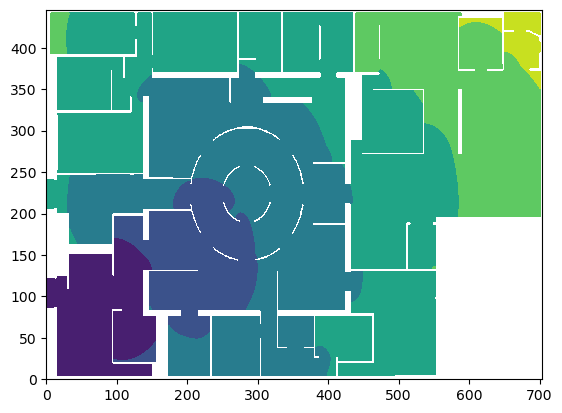

In [18]:
if scheme.values.shape[0]<10: print(scheme.values.to_numpy())
else: plt.contourf(scheme.values.to_numpy())

In [19]:
# Average number of updates per point
scheme.nupdates[None]/np.prod(cost.shape)

np.float64(1.9963444238183636)

## 3. Adaptive Gauss-Siedel iteration

This simpler algorithm does not use any sorting, and does not require the scheme to obey the causality property. 
On the other hand it requires a tolerance parameter $\epsilon>0$, and has a super-linear complexity $\cO(N^{1+1/d})$ in the worst case.

### 3.1 FIFO queue

The First in first out (FIFO) queue yields elements in the order in which they were inserted.

In [27]:
fifo = fifo_queue(ti.i32)
for i in [1,2,1,3,4,2]: fifo.push(i)
while not fifo.empty(): 
    print(f"top : {fifo.front()}, number of elements : {fifo.size}")
    fifo.pop()

top : 1, number of elements : 6
top : 2, number of elements : 5
top : 1, number of elements : 4
top : 3, number of elements : 3
top : 4, number of elements : 2
top : 2, number of elements : 1


### 3.2 Implementation

The AGSI uses a fifo queue, with the following rules:
- Each point appears at most once in the queue.
- When a point is extracted from the queue, the corresponding update is computed.
- The update is applied if it decreases the solution value more than the chosen tolerance, and in that case the neighbors of these points are pushed into the queue.

<!---ExoEN
Complete the implementation of the AGSI.
--->

<!---ExoCode
scheme = RouyTourinScheme(cost)
fifo = fifo_queue(ti.math.ivec2,capacity=np.prod(cost.shape))
infifo = ti.field(dtype=ti.u1,shape=cost.shape); infifo.fill(False)

@ti.pyfunc
def AGSI_push(y):
    """Push y into the fifo queue, if it is not already there, and update the infifo field."""
    if not infifo[*y]: fifo.push(y); infifo[*y]=True

@ti.pyfunc
def AGSI_set_seed(y,value):
    """Set the value at the point y, which will be frozen, and insert in queue"""
    scheme.values[*y] = value
    scheme.neigh(y,AGSI_push)

@ti.kernel
def AGSI_run(tol:float_t):
    for _ in range(1):
        while not fifo.empty() and fifo.size < fifo.capacity-4:
            x = fifo.front()
            fifo.pop()
            infifo[x] = False
            λ = scheme.update(x)
            if λ < scheme.values[x]-tol: 
                # TODO : update the solution value
                # TODO : push the neighbors of x into the fifo queue (hint : scheme.neigh with adequate callback)
--->


In [29]:
scheme = RouyTourinScheme(cost)
fifo = fifo_queue(ti.math.ivec2,capacity=np.prod(cost.shape))
infifo = ti.field(dtype=ti.u1,shape=cost.shape); infifo.fill(False)

@ti.pyfunc
def AGSI_push(y):
    """Push y into the fifo queue, if it is not already there, and update the infifo field."""
    if not infifo[*y]: fifo.push(y); infifo[*y]=True

@ti.pyfunc
def AGSI_set_seed(y,value):
    """Set the value at the point y, which will be frozen, and insert in queue"""
    scheme.values[*y] = value
    scheme.neigh(y,AGSI_push)

@ti.kernel
def AGSI_run(tol:float_t):
    for _ in range(1):
        while not fifo.empty() and fifo.size < fifo.capacity-4:
            x = fifo.front()
            fifo.pop()
            infifo[x] = False
            λ = scheme.update(x)
            if λ < scheme.values[x]-tol: 
                scheme.values[x] = λ
                scheme.neigh(x,AGSI_push)

In [30]:
AGSI_set_seed(seed,0.)
AGSI_run(tol=1e-6)

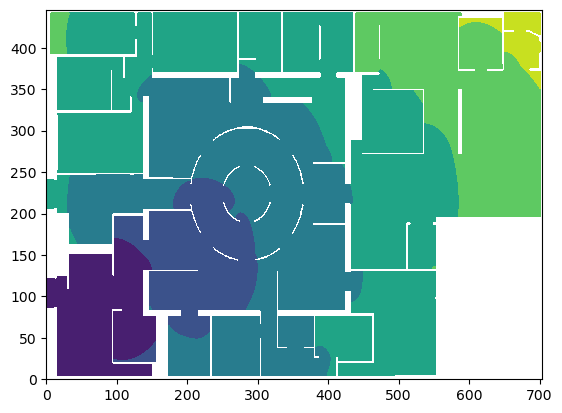

In [31]:
if scheme.values.shape[0]<10: print(scheme.values.to_numpy())
else: plt.contourf(scheme.values.to_numpy())

In [32]:
# Average number of updates per point
scheme.nupdates[None]/np.prod(cost.shape)

np.float64(1.784067145826392)

### 4. Fast-sweeping

The fast sweeping method uses no queue at all, and is easily parallelized.

The idea is to update all columns of the domain, from left to right and then in reverse, then update all lines of the image, from top to bottom and then in reverse, etc.

<!---ExoEN
Complete the following implementation of the fast sweeping method.
--->

<!---ExoCode
scheme = RouyTourinScheme(cost)
updated = ti.field(ti.u1,shape=()); updated[None]=True
tol=1e-6

@ti.pyfunc
def FS_set_seed(y,value):
    scheme.values[*y] = value

@ti.kernel
def FS_update(axis:ti.template(),coord:ti.i32):
    """Update all points x such that x[axis]==coord, in parallel"""
    oaxis = ti.static(1-axis)
    for i in range(1,cost.shape[oaxis]-1): # Parallized loop over all points of the other axis.
        x = ti.math.ivec2(0,0); x[axis]=coord; x[oaxis]=i
        λ = scheme.update(x)
        if λ < scheme.values[x]-tol: 
            updated[None]=True
            scheme.values[x] = λ

def FS_run(nitermax=1000):
    """The fast sweeping algorithm."""
    for niter in range(nitermax):
        updated[None] = False
        for axis in (0,1): 
            # TODO : update all points, sorted by *increasing* coordinate along the current axis
            # TODO : update all points, sorted by *decreasing* coordinate along the current axis
        if not updated[None]: break
--->

In [33]:
scheme = RouyTourinScheme(cost)
updated = ti.field(ti.u1,shape=()); updated[None]=True
tol=1e-6

@ti.pyfunc
def FS_set_seed(y,value):
    scheme.values[*y] = value

@ti.kernel
def FS_update(axis:ti.template(),coord:ti.i32):
    """Update all points x such that x[axis]=coord, in parallel"""
    oaxis = ti.static(1-axis)
    for i in range(1,cost.shape[oaxis]-1): # Parallized loop over all points of the other axis.
        x = ti.math.ivec2(0,0); x[axis]=coord; x[oaxis]=i
        λ = scheme.update(x)
        if λ < scheme.values[x]-tol: 
            updated[None]=True
            scheme.values[x] = λ

def FS_run(nitermax=1000):
    """The fast sweeping algorithm."""
    for niter in range(nitermax):
        updated[None] = False
        for axis in (0,1): 
            for i in range(cost.shape[axis]): FS_update(axis,i)
            for i in reversed(range(cost.shape[axis])): FS_update(axis,i)
        if not updated[None]: break
        

In [34]:
FS_set_seed(seed,0.)
FS_run()

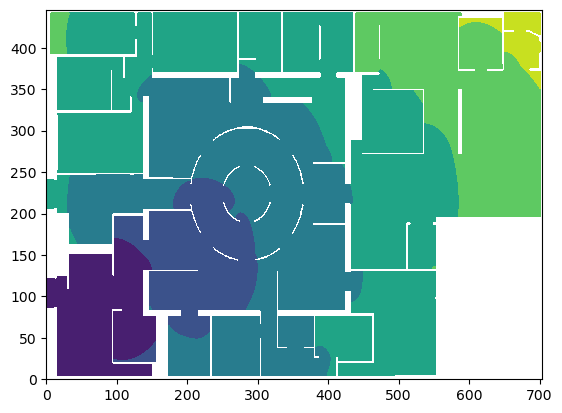

In [35]:
if scheme.values.shape[0]<10: print(scheme.values.to_numpy())
else: plt.contourf(scheme.values.to_numpy())

In [36]:
# Average number of updates per point
scheme.nupdates[None]/np.prod(cost.shape)

np.float64(175.356618592032)